In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['Copy of Welcome To Colab', 'Practice', 'College CW', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled0.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'ML ASSIGNIMENT 2.ipynb', 'Untitled6.ipynb', 'AI PROJECTS', 'Copy of util.ipynb', 'Untitled5.ipynb', 'Untitled (1)', 'Untitled7.ipynb', 'ML ASSIGNMENT', 'DSA Assignment', 'DS COURSE', 'ML ASSIGNMENT 1.ipynb', 'Untitled', 'ML_Spam_email_detection.ipynb', 'ChurnPrediction.ipynb', 'ML Project', 'PyTorch', 'DL Project', 'DL project Test']


In [3]:
# train_rgb_path = "/content/drive/MyDrive/DL Project/Kaggle_Prepared/train/RGB"
train_rgb_path = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/RGB"
rgb_files = os.listdir(train_rgb_path)
print("Total RGB files:", len(rgb_files))
print(rgb_files[:10])

Total RGB files: 600
['Other_hyper_33.png', 'Rust_hyper_60.png', 'Rust_hyper_49.png', 'Other_hyper_195.png', 'Health_hyper_9.png', 'Other_hyper_196.png', 'Rust_hyper_9.png', 'Health_hyper_41.png', 'Other_hyper_61.png', 'Rust_hyper_176.png']


## Data Preparation & Splitting

In [4]:
health_rgb = []

for f in rgb_files:
    if "Health" in f:
        health_rgb.append(f)


rust_rgb = []

for f in rgb_files:
    if "Rust" in f:
        rust_rgb.append(f)


other_rgb = []

for f in rgb_files:
    if "Other" in f:
        other_rgb.append(f)

print(len(health_rgb), len(rust_rgb), len(other_rgb))


200 200 200


In [5]:
print(health_rgb[:10])
print(rust_rgb[:10])
print(other_rgb[:10])

['Health_hyper_9.png', 'Health_hyper_41.png', 'Health_hyper_32.png', 'Health_hyper_19.png', 'Health_hyper_85.png', 'Health_hyper_167.png', 'Health_hyper_175.png', 'Health_hyper_154.png', 'Health_hyper_132.png', 'Health_hyper_27.png']
['Rust_hyper_60.png', 'Rust_hyper_49.png', 'Rust_hyper_9.png', 'Rust_hyper_176.png', 'Rust_hyper_191.png', 'Rust_hyper_38.png', 'Rust_hyper_73.png', 'Rust_hyper_200.png', 'Rust_hyper_18.png', 'Rust_hyper_57.png']
['Other_hyper_33.png', 'Other_hyper_195.png', 'Other_hyper_196.png', 'Other_hyper_61.png', 'Other_hyper_14.png', 'Other_hyper_84.png', 'Other_hyper_133.png', 'Other_hyper_54.png', 'Other_hyper_125.png', 'Other_hyper_124.png']


In [6]:
import random

random.shuffle(health_rgb)
random.shuffle(rust_rgb)
random.shuffle(other_rgb)


In [7]:
# Health Split
train_health = health_rgb[:160]
val_health   = health_rgb[160:]

# Rust Split
train_rust = rust_rgb[:160]
val_rust   = rust_rgb[160:]

# Other Split
train_other = other_rgb[:160]
val_other   = other_rgb[160:]


print(len(train_health), len(val_health))
print(len(train_rust), len(val_rust))
print(len(train_other), len(val_other))


160 40
160 40
160 40


In [8]:
train_files = train_health + train_rust + train_other
val_files   = val_health + val_rust + val_other

In [9]:
train_data = []

# Health = 0
for f in train_health:
    train_data.append((f, 0))

# Rust = 1
for f in train_rust:
    train_data.append((f, 1))

# Other = 2
for f in train_other:
    train_data.append((f, 2))

print(len(train_data))


480


In [10]:
val_data = []

# Health = 0
for f in val_health:
    val_data.append((f, 0))

# Rust = 1
for f in val_rust:
    val_data.append((f, 1))

# Other = 2
for f in val_other:
    val_data.append((f, 2))

print(len(val_data))


120


In [11]:
# But inside train_data, the order is:

# All Health (160)
# All Rust (160)
# All Other (160)
# That is NOT ideal for training.


random.shuffle(train_data)
random.shuffle(val_data)

#CNN MODEL for RGB Images

In [12]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
from sklearn.metrics import accuracy_score , classification_report
import numpy as np
import rasterio

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [14]:
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import os

def apply_clahe(pil_img):
    img_np = np.array(pil_img, dtype=np.uint8)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb)

class RGBDataset(Dataset):
    def __init__(self, folder, file_list, transform=None):
        self.folder    = folder
        self.files     = sorted(file_list)
        self.transform = transform  # handles both augment + normalize

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file  = self.files[idx]
        path  = os.path.join(self.folder, file)

        image = Image.open(path).convert("RGB")
        image = apply_clahe(image)   # CLAHE first, before any transform

        file_lower = file.lower()
        if "health" in file_lower:
            label = 0
        elif "rust" in file_lower:
            label = 1
        elif "other" in file_lower:
            label = 2
        else:
            raise ValueError(f"Unknown label: {file}")

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
print([v for v in dir() if 'train' in v.lower() and ('stem' in v.lower() or 'file' in v.lower())])

['train_files']


In [16]:
import cv2
import numpy as np

def apply_clahe(pil_img):
    img_np = np.array(pil_img, dtype=np.uint8)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

class CLAHETransform:
    def __call__(self, img):
        return apply_clahe(img)

# Fix 1: Compute YOUR stats from training data — not ImageNet
def compute_rgb_stats(folder, file_list):
    means, stds = [], []
    for f in file_list:
        img_path = os.path.join(folder, f)  # no extension added — already has .png
        img = np.array(Image.open(img_path).convert("RGB")).astype(np.float32) / 255.0
        means.append(img.mean(axis=(0, 1)))
        stds.append(img.std(axis=(0, 1)))
    mean = np.mean(means, axis=0).tolist()
    std  = np.mean(stds,  axis=0).tolist()
    print(f"RGB Mean: {[round(m, 4) for m in mean]}")
    print(f"RGB Std:  {[round(s, 4) for s in std]}")
    return mean, std

RGB_MEAN, RGB_STD = compute_rgb_stats(train_rgb_path, train_files)

# Fix 2: Remove ColorJitter + RandomGrayscale (distort synthetic spectral colour)
# Fix 3: CLAHE first — before any geometric augmentation
train_transform = transforms.Compose([
    CLAHETransform(),                                    # contrast fix for synthetic RGB
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    # NO ColorJitter  — destroys synthetic spectral values
    # NO RandomGrayscale — removes the spectral colour entirely
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),             # your stats, not ImageNet
    transforms.RandomErasing(p=0.2),                     # kept — spatial masking is fine
])

val_transform = transforms.Compose([
    CLAHETransform(),                                    # apply CLAHE at val time too
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),             # your stats, not ImageNet
])

RGB Mean: [0.4293, 0.4551, 0.4349]
RGB Std:  [0.2364, 0.2338, 0.2371]


In [17]:
train_dataset = RGBDataset(train_rgb_path, train_files, train_transform)
val_dataset   = RGBDataset(train_rgb_path, val_files,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}  |  Val samples: {len(val_dataset)}")


Train samples: 480  |  Val samples: 120


In [18]:
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze only the stem (conv1 + bn1) — keeps low-level edge detectors fixed
# Unfreeze layer1–layer4 so they adapt to synthetic RGB data
for name, param in model.named_parameters():
    if any(x in name for x in ["conv1", "bn1"]):
        param.requires_grad = False  # freeze stem only
    else:
        param.requires_grad = True   # fine-tune all other layers

# Replace head with stronger classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 3)
)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Trainable params: 6,609,923 / 11,341,891


In [19]:
def train_model(model, train_loader, val_loader, epochs=30):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_acc, best_epoch, no_improve = 0.0, 0, 0
    patience = 10

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                preds = torch.argmax(model(images), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc      = accuracy_score(all_labels, all_preds)
        avg_loss = train_loss / len(train_loader)

        if acc > best_acc:
            best_acc, best_epoch, no_improve = acc, epoch+1, 0
            torch.save(model.state_dict(), "best_rgb_model.pth")
            marker = "  ← best"
        else:
            no_improve += 1
            marker = ""

        print(f"Epoch {epoch+1:>2}/{epochs}  |  Loss: {avg_loss:.4f}  |  "
              f"Val Acc: {acc:.4f}" + marker)

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest Val Accuracy: {best_acc:.4f}  (Epoch {best_epoch})")

In [20]:

def evaluate(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds   = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n── Final Evaluation ──")
    print(classification_report(
        all_labels, all_preds,
        target_names=["Health", "Rust", "Other"]
    ))

In [21]:
# Step 1 — make sure model is defined (run the ResNet18 cell)
# Step 2 — make sure dataloaders exist (run the dataloader cell)
# Step 3 — train first, THEN evaluate

train_model(model, train_loader, val_loader, epochs=30)

# Step 4 — only load after training completes
model.load_state_dict(torch.load("best_rgb_model.pth", map_location=device))
model.to(device)
evaluate(model, val_loader)

Epoch  1/30  |  Loss: 1.1042  |  Val Acc: 0.4750  ← best
Epoch  2/30  |  Loss: 1.0115  |  Val Acc: 0.4833  ← best
Epoch  3/30  |  Loss: 0.9998  |  Val Acc: 0.4667
Epoch  4/30  |  Loss: 0.9834  |  Val Acc: 0.5167  ← best
Epoch  5/30  |  Loss: 0.9868  |  Val Acc: 0.4583
Epoch  6/30  |  Loss: 0.9530  |  Val Acc: 0.5167
Epoch  7/30  |  Loss: 0.9570  |  Val Acc: 0.5583  ← best
Epoch  8/30  |  Loss: 0.9514  |  Val Acc: 0.5250
Epoch  9/30  |  Loss: 0.9747  |  Val Acc: 0.4583
Epoch 10/30  |  Loss: 0.9421  |  Val Acc: 0.4667
Epoch 11/30  |  Loss: 0.9595  |  Val Acc: 0.5000
Epoch 12/30  |  Loss: 0.9505  |  Val Acc: 0.5083
Epoch 13/30  |  Loss: 0.9368  |  Val Acc: 0.4750
Epoch 14/30  |  Loss: 0.9079  |  Val Acc: 0.5167
Epoch 15/30  |  Loss: 0.9478  |  Val Acc: 0.5333
Epoch 16/30  |  Loss: 0.9386  |  Val Acc: 0.5167
Epoch 17/30  |  Loss: 0.9194  |  Val Acc: 0.5333

Early stopping at epoch 17

Best Val Accuracy: 0.5583  (Epoch 7)

── Final Evaluation ──
              precision    recall  f1-score  

#CNN MODEL for MS Data

In [22]:
import os
ms_path = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/MS"
files = os.listdir(ms_path)
print(f"Total files: {len(files)}")
print("First 10 files:", files[:10])
print("Extension:", os.path.splitext(files[0])[1])

Total files: 600
First 10 files: ['Other_hyper_100.tif', 'Health_hyper_39.tif', 'Health_hyper_49.tif', 'Health_hyper_132.tif', 'Health_hyper_119.tif', 'Other_hyper_183.tif', 'Other_hyper_138.tif', 'Other_hyper_184.tif', 'Health_hyper_152.tif', 'Health_hyper_121.tif']
Extension: .tif


In [23]:
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train"))

['.DS_Store', 'MS', 'HS', 'RGB']


In [24]:
import warnings
import rasterio
import rasterio.errors
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

# Also suppress in worker processes
import os
os.environ["RASTERIO_IGNORE_GEOREF_WARNING"] = "1"

In [25]:
sample = os.path.join(ms_path, files[0])

ext = os.path.splitext(files[0])[1].lower()
if ext == ".npy":
    arr = np.load(sample)
    print("Shape:", arr.shape)
    print("Dtype:", arr.dtype)
    print("Min/Max:", arr.min(), arr.max())
elif ext in (".tif", ".tiff"):
    import rasterio
    with rasterio.open(sample) as src:
        print("Bands:", src.count)
        print("Shape:", src.height, src.width)
        print("Dtype:", src.dtypes)
elif ext == ".png":
    from PIL import Image
    img = Image.open(sample)
    print("Mode:", img.mode)
    print("Size:", img.size)

Bands: 5
Shape: 64 64
Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16')


In [26]:
# ── File split ────────────────────────────────────────────────
ms_files = os.listdir(ms_path)
health_ms, rust_ms, other_ms = [], [], []
for f in ms_files:
    if   "Health" in f: health_ms.append(f)
    elif "Rust"   in f: rust_ms.append(f)
    elif "Other"  in f: other_ms.append(f)

print(f"Health: {len(health_ms)}  Rust: {len(rust_ms)}  Other: {len(other_ms)}")

random.seed(42)
random.shuffle(health_ms)
random.shuffle(rust_ms)
random.shuffle(other_ms)

train_files = health_ms[:160] + rust_ms[:160] + other_ms[:160]
val_files   = health_ms[160:] + rust_ms[160:] + other_ms[160:]
random.shuffle(train_files)
random.shuffle(val_files)
print(f"Train: {len(train_files)}  |  Val: {len(val_files)}")

Health: 200  Rust: 200  Other: 200
Train: 480  |  Val: 120


In [27]:
class MSDataset(Dataset):
    def __init__(self, folder, file_list, mean, std, augment=False):
        self.folder  = folder
        self.files   = sorted(file_list)
        self.mean    = torch.tensor(mean, dtype=torch.float32).view(5, 1, 1)
        self.std     = torch.tensor(std,  dtype=torch.float32).view(5, 1, 1)
        self.augment = augment
        self.resize  = transforms.Resize(
            (112, 112),                        # 112 instead of 224 — less overfitting
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=True
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        path = os.path.join(self.folder, file)

        file_lower = file.lower()
        if   "health" in file_lower: label = 0
        elif "rust"   in file_lower: label = 1
        elif "other"  in file_lower: label = 2
        else: raise ValueError(f"Unknown label: {file}")

        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32) / 65535.0   # (5, 64, 64)

        tensor = torch.from_numpy(arr)
        tensor = self.resize(tensor)                         # (5, 112, 112)
        tensor = (tensor - self.mean) / (self.std + 1e-6)   # normalise

        if self.augment:
            # Spatial augmentations
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[2])        # h-flip
            if random.random() > 0.5:
                tensor = torch.flip(tensor, dims=[1])        # v-flip
            k = random.randint(0, 3)
            if k > 0:
                tensor = torch.rot90(tensor, k, dims=[1, 2])

            # Spectral augmentation — randomly scale individual bands slightly
            # Simulates sensor noise and varying illumination per band
            scale = torch.empty(5, 1, 1).uniform_(0.9, 1.1)
            tensor = tensor * scale

            # Random band dropout — force model to not rely on any single band
            # Randomly zero out one band with 20% probability
            if random.random() < 0.2:
                band_idx = random.randint(0, 4)
                tensor[band_idx] = 0.0

        return tensor, label

In [28]:
print("\nComputing per-band statistics...")
channel_sum  = np.zeros(5, dtype=np.float64)
channel_sum2 = np.zeros(5, dtype=np.float64)
n_pixels     = 0

for f in train_files:
    with rasterio.open(os.path.join(ms_path, f)) as src:
        arr = src.read().astype(np.float64) / 65535.0
    channel_sum  += arr.sum(axis=(1, 2))
    channel_sum2 += (arr ** 2).sum(axis=(1, 2))
    n_pixels     += arr.shape[1] * arr.shape[2]

MEAN = (channel_sum  / n_pixels).tolist()
STD  = (np.sqrt(channel_sum2 / n_pixels - (channel_sum / n_pixels) ** 2)).tolist()
print(f"Mean: {[round(m,4) for m in MEAN]}")
print(f"Std : {[round(s,4) for s in STD]}")


Computing per-band statistics...
Mean: [0.0063, 0.0116, 0.0122, 0.0331, 0.0407]
Std : [0.0057, 0.0071, 0.0102, 0.0131, 0.0172]


In [29]:
# ── DataLoaders ───────────────────────────────────────────────
train_dataset = MSDataset(ms_path, train_files, MEAN, STD, augment=True)
val_dataset   = MSDataset(ms_path, val_files,   MEAN, STD, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f"\nBatch shape : {imgs.shape}")    # (32, 5, 112, 112)
print(f"Labels      : {lbls.tolist()}")


Batch shape : torch.Size([32, 5, 112, 112])
Labels      : [1, 1, 2, 1, 2, 2, 0, 0, 1, 1, 0, 0, 1, 0, 2, 2, 1, 1, 0, 0, 0, 2, 0, 2, 2, 1, 0, 2, 0, 2, 1, 2]


In [30]:
# ── Model: ResNet18 with 5-channel input ──────────────────────
def build_ms_resnet(in_channels=5, num_classes=3):
    model    = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    old_conv = model.conv1

    new_conv = nn.Conv2d(
        in_channels,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        # Copy pretrained RGB weights into first 3 channels
        new_conv.weight[:, :3, :, :] = old_conv.weight
        # Initialise extra channels (4, 5) as mean of RGB weights
        extra = old_conv.weight.mean(dim=1, keepdim=True)
        for i in range(3, in_channels):
            new_conv.weight[:, i:i+1, :, :] = extra

    model.conv1 = new_conv

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = build_ms_resnet(in_channels=5, num_classes=3).to(device)
print(f"\nModel ready — input channels: 5")


Model ready — input channels: 5


In [31]:
# ── Training ──────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=30):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
    head_params     = list(model.fc.parameters())

    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": 1e-4},
        {"params": head_params,     "lr": 1e-3},
    ], weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    best_acc   = 0.0
    best_epoch = 0
    patience   = 10
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                preds = torch.argmax(model(images), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc      = accuracy_score(all_labels, all_preds)
        avg_loss = train_loss / len(train_loader)
        cur_lr   = optimizer.param_groups[1]["lr"]

        if acc > best_acc:
            best_acc   = acc
            best_epoch = epoch + 1
            no_improve = 0
            torch.save(model.state_dict(), "best_ms_model.pth")
            marker = "  ← best"
        else:
            no_improve += 1
            marker = ""

        print(f"Epoch {epoch+1:>2}/{epochs}  |  "
              f"Loss: {avg_loss:.4f}  |  "
              f"Val Acc: {acc:.4f}  |  "
              f"LR: {cur_lr:.2e}" + marker)

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest Val Accuracy: {best_acc:.4f}  (Epoch {best_epoch})")


def evaluate_ms(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n── Multispectral Final Evaluation ──")
    print(classification_report(
        all_labels, all_preds,
        target_names=["Health", "Rust", "Other"]
    ))


In [32]:
# ── Run ───────────────────────────────────────────────────────
train_model(model, train_loader, val_loader, epochs=30)
model.load_state_dict(torch.load("best_ms_model.pth"))
evaluate_ms(model, val_loader)

Epoch  1/30  |  Loss: 1.0604  |  Val Acc: 0.6000  |  LR: 9.97e-04  ← best
Epoch  2/30  |  Loss: 0.9165  |  Val Acc: 0.5500  |  LR: 9.89e-04
Epoch  3/30  |  Loss: 0.8749  |  Val Acc: 0.6417  |  LR: 9.76e-04  ← best
Epoch  4/30  |  Loss: 0.8382  |  Val Acc: 0.6750  |  LR: 9.57e-04  ← best
Epoch  5/30  |  Loss: 0.7767  |  Val Acc: 0.6917  |  LR: 9.33e-04  ← best
Epoch  6/30  |  Loss: 0.7946  |  Val Acc: 0.6500  |  LR: 9.05e-04
Epoch  7/30  |  Loss: 0.7328  |  Val Acc: 0.7333  |  LR: 8.72e-04  ← best
Epoch  8/30  |  Loss: 0.7388  |  Val Acc: 0.6333  |  LR: 8.35e-04
Epoch  9/30  |  Loss: 0.6950  |  Val Acc: 0.6583  |  LR: 7.94e-04
Epoch 10/30  |  Loss: 0.6808  |  Val Acc: 0.6583  |  LR: 7.50e-04
Epoch 11/30  |  Loss: 0.6532  |  Val Acc: 0.6583  |  LR: 7.04e-04
Epoch 12/30  |  Loss: 0.6436  |  Val Acc: 0.6167  |  LR: 6.55e-04
Epoch 13/30  |  Loss: 0.6293  |  Val Acc: 0.6500  |  LR: 6.04e-04
Epoch 14/30  |  Loss: 0.5739  |  Val Acc: 0.6583  |  LR: 5.53e-04
Epoch 15/30  |  Loss: 0.5497  |  Val

#CNN for HS Data

In [33]:
# Find the hyperspectral folder
hs_path = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/HS"

In [34]:
# update name if different

files = os.listdir(hs_path)
print(f"Total files: {len(files)}")
print("Sample files:", files[:5])

# Check one file
with rasterio.open(os.path.join(hs_path, files[0])) as src:
    print(f"\nBands  : {src.count}")
    print(f"Shape  : {src.height} x {src.width}")
    print(f"Dtype  : {src.dtypes[0]}")

Total files: 600
Sample files: ['Health_hyper_134.tif', 'Health_hyper_120.tif', 'Health_hyper_11.tif', 'Health_hyper_123.tif', 'Health_hyper_125.tif']

Bands  : 125
Shape  : 32 x 32
Dtype  : uint16


In [35]:
# ── File split ────────────────────────────────────────────────
hs_files = os.listdir(hs_path)
health_hs, rust_hs, other_hs = [], [], []
for f in hs_files:
    if   "Health" in f: health_hs.append(f)
    elif "Rust"   in f: rust_hs.append(f)
    elif "Other"  in f: other_hs.append(f)

print(f"Health: {len(health_hs)}  Rust: {len(rust_hs)}  Other: {len(other_hs)}")

random.seed(42)
random.shuffle(health_hs)
random.shuffle(rust_hs)
random.shuffle(other_hs)

train_files = health_hs[:160] + rust_hs[:160] + other_hs[:160]
val_files   = health_hs[160:] + rust_hs[160:] + other_hs[160:]
random.shuffle(train_files)
random.shuffle(val_files)
print(f"Train: {len(train_files)}  |  Val: {len(val_files)}")




Health: 200  Rust: 200  Other: 200
Train: 480  |  Val: 120


In [36]:
# ── Check band counts across all files ───────────────────────


HS_BAND_START = 10   # 450 + 10*4 = 490nm
HS_BAND_END   = 111  # 450 + 111*4 = 894nm
HS_BANDS      = 101  # clean bands only

print("Checking band counts across all files...")
band_counts = {}
for f in hs_files:
    with rasterio.open(os.path.join(hs_path, f)) as src:
        n = src.count
    band_counts[n] = band_counts.get(n, 0) + 1
print("Band count distribution:", band_counts)

N_BANDS_RAW = max(band_counts, key=band_counts.get)
print(f"Raw bands in files : {N_BANDS_RAW}")
print(f"Clean bands to use : {HS_BANDS} (trimmed {HS_BAND_START} front, {N_BANDS_RAW - HS_BAND_END} back)")

# ── Compute statistics on CLEAN bands only (101 bands) ────────
print(f"\nComputing per-band statistics ({HS_BANDS} clean bands)...")
channel_sum  = np.zeros(HS_BANDS, dtype=np.float64)
channel_sum2 = np.zeros(HS_BANDS, dtype=np.float64)
n_pixels     = 0
skipped      = 0

for f in train_files:
    with rasterio.open(os.path.join(hs_path, f)) as src:
        arr = src.read().astype(np.float64) / 65535.0   # (125, H, W)

    # Skip files with fewer bands than expected
    if arr.shape[0] < N_BANDS_RAW:
        skipped += 1
        continue

    # Trim to clean bands — same as HSDataset
    arr = arr[HS_BAND_START:HS_BAND_END]                # (101, H, W)

    channel_sum  += arr.sum(axis=(1, 2))
    channel_sum2 += (arr ** 2).sum(axis=(1, 2))
    n_pixels     += arr.shape[1] * arr.shape[2]

if skipped > 0:
    print(f"Skipped {skipped} files with fewer than {N_BANDS_RAW} bands")

HS_MEAN = (channel_sum  / n_pixels).tolist()
HS_STD  = (np.sqrt(channel_sum2 / n_pixels - (channel_sum / n_pixels) ** 2)).tolist()

print(f"Mean range : [{min(HS_MEAN):.4f}, {max(HS_MEAN):.4f}]")
print(f"Std  range : [{min(HS_STD):.4f},  {max(HS_STD):.4f}]")
print(f"Stats computed for {HS_BANDS} clean bands ✓")

Checking band counts across all files...
Band count distribution: {125: 489, 126: 111}
Raw bands in files : 125
Clean bands to use : 101 (trimmed 10 front, 14 back)

Computing per-band statistics (101 clean bands)...
Mean range : [0.0067, 0.0415]
Std  range : [0.0057,  0.0169]
Stats computed for 101 clean bands ✓


In [37]:
from torch.utils.data import Dataset

# Clean band range based on S185 sensor spec
# HS_BAND_START = 10   # 450 + 10*4 = 490nm
# HS_BAND_END   = 111  # 450 + 111*4 = 894nm
# HS_BANDS      = 101  # clean bands only

class HSDataset(Dataset):
    def __init__(self, folder, file_list, mean, std, augment=False):
        self.folder  = folder
        self.files   = sorted(file_list)
        self.mean    = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std     = torch.tensor(std,  dtype=torch.float32).view(-1, 1, 1)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file       = self.files[idx]
        path       = os.path.join(self.folder, file)
        file_lower = file.lower()

        if   'health' in file_lower: label = 0
        elif 'rust'   in file_lower: label = 1
        elif 'other'  in file_lower: label = 2
        else: raise ValueError(f'Unknown label: {file}')

        # ── Load and trim noisy bands ──
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32) / 65535.0  # (125, H, W)

        # Remove first 10 (450–486nm) and last 14 (894–946nm) noisy bands
        arr = arr[HS_BAND_START:HS_BAND_END, :, :]         # (101, H, W)

        # ── Convert to tensor ──
        tensor = torch.from_numpy(arr).float()

        # ── Normalize ──
        tensor = (tensor - self.mean) / (self.std + 1e-6)

        # ── Augmentation ──
        if self.augment:
            if random.random() < 0.5:
                tensor = torch.flip(tensor, dims=[2])       # horizontal
            if random.random() < 0.5:
                tensor = torch.flip(tensor, dims=[1])       # vertical

            k = random.randint(0, 3)
            if k:
                tensor = torch.rot90(tensor, k, dims=[1, 2])

            if random.random() < 0.7:
                noise = torch.randn_like(tensor) * 0.02
                tensor = tensor + noise

            if random.random() < 0.7:
                scale = torch.empty(tensor.shape[0], 1, 1).uniform_(0.9, 1.1)
                tensor = tensor * scale

            if random.random() < 0.5:
                n_drop = random.randint(1, 6)
                drop_idx = torch.randperm(tensor.shape[0])[:n_drop]
                tensor[drop_idx] = 0.0

            if random.random() < 0.3:
                shift = random.randint(-3, 3)
                tensor = torch.roll(tensor, shifts=shift, dims=0)

            tensor = torch.clamp(tensor, -3, 3)

        return tensor, label

In [38]:
# ── DataLoaders ───────────────────────────────────────────────
train_dataset = HSDataset(hs_path, train_files, HS_MEAN, HS_STD, augment=True)
val_dataset   = HSDataset(hs_path, val_files,   HS_MEAN, HS_STD, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print(f"Value range : [{imgs.min():.2f}, {imgs.max():.2f}]")

Batch shape : torch.Size([32, 101, 32, 32])
Value range : [-2.91, 3.00]


In [39]:
# ── Spectral Self-Attention Block ─────────────────────────────
class SpectralSelfAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.pool(x)
        w = self.fc(w)
        return x * w


# ── NEW: Spectral Attention Pooling (🔥 BIG UPGRADE) ──────────
class SpectralAttentionPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(),
            nn.Conv2d(channels // 8, 1, 1)  # attention map
        )

    def forward(self, x):
        B, C, H, W = x.shape

        attn_map = self.attn(x)                # (B, 1, H, W)
        attn_map = attn_map.view(B, 1, -1)
        attn_map = torch.softmax(attn_map, dim=-1)

        x_flat = x.view(B, C, -1)              # (B, C, H*W)
        weighted = (x_flat * attn_map).sum(dim=-1)  # (B, C)

        return weighted


# ── Model v4 (UPGRADED) ───────────────────────────────────────
class HybridHSModel(nn.Module):
    def __init__(self, n_bands=101, num_classes=3):
        super().__init__()

        self.input_attn = SpectralSelfAttention(n_bands)

        # 🔥 NEW pooling
        self.spec_pool = SpectralAttentionPooling(n_bands)

        # ── Spectral branch ──
        self.spectral_branch = nn.Sequential(
            nn.Conv1d(1, 32,  kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),

            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),   # 🔥 reduced from 0.4

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
        )

        # ── Spatial branch ──
        self.spatial_branch = nn.Sequential(
            nn.Conv2d(n_bands, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
        )

        # ── Classifier ──
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.input_attn(x)

        # NEW: Attention pooling instead of mean
        x_spec = self.spec_pool(x).unsqueeze(1)   # (B,1,C)
        x_spec = self.spectral_branch(x_spec)

        x_spat = self.spatial_branch(x)

        return self.classifier(torch.cat([x_spec, x_spat], dim=1))

In [40]:
model = HybridHSModel(n_bands=101, num_classes=3).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready — HS bands : 101 (trimmed from 125)")
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Model ready — HS bands : 101 (trimmed from 125)
Trainable params: 1,605,729 / 1,605,729


In [41]:
# ── Mixup helper ──────────────────────────────────────────────
def mixup_batch(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    return x_mix, y, y[idx], lam

# ── Training ──────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

def train_model(model, train_loader, val_loader, epochs=50):
    # Collect all labels from training set
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.numpy())
    all_labels = np.array(all_labels)

    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(all_labels),
        y=all_labels
    )
    weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"Class Weights: {weights}")

    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

    backbone_params = [p for n, p in model.named_parameters()
                       if "classifier" not in n]
    head_params     = list(model.classifier.parameters())

    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": 5e-5},  # reduced — 101 bands needs gentler LR
        {"params": head_params,     "lr": 5e-4},  # reduced — more stable
    ], weight_decay=1e-4)

    # Warmup 5 epochs then cosine decay
    def lr_lambda(epoch):
        warmup_epochs = 5
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_acc   = 0.0
    best_epoch = 0
    patience   = 15     # more patience — HS needs more epochs to converge
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        # ── Validation ──
        model.eval()
        all_preds, all_labels_val = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                preds = torch.argmax(model(images), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_val.extend(labels.cpu().numpy())

        acc      = accuracy_score(all_labels_val, all_preds)
        avg_loss = train_loss / len(train_loader)
        cur_lr   = optimizer.param_groups[1]["lr"]

        if acc > best_acc:
            best_acc   = acc
            best_epoch = epoch + 1
            no_improve = 0
            torch.save(model.state_dict(), "best_hs_model.pth")
            marker = "  ← best"
        else:
            no_improve += 1
            marker = ""

        print(f"Epoch {epoch+1:>2}/{epochs}  |  "
              f"Loss: {avg_loss:.4f}  |  "
              f"Val Acc: {acc:.4f}  |  "
              f"LR: {cur_lr:.2e}" + marker)

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest Val Accuracy: {best_acc:.4f}  (Epoch {best_epoch})")

In [42]:
# ── Freeze Spatial Branch (Phase 1) ──────────────────────────
for name, param in model.named_parameters():
    if "spatial_branch" in name:
        param.requires_grad = False

print("Phase 1: Spatial branch frozen")

Phase 1: Spatial branch frozen


In [43]:
train_model(model, train_loader, val_loader, epochs=30)

Class Weights: tensor([1., 1., 1.], device='cuda:0')
Epoch  1/30  |  Loss: 1.1596  |  Val Acc: 0.3333  |  LR: 2.00e-04  ← best
Epoch  2/30  |  Loss: 1.0645  |  Val Acc: 0.3667  |  LR: 3.00e-04  ← best
Epoch  3/30  |  Loss: 0.9919  |  Val Acc: 0.5500  |  LR: 4.00e-04  ← best
Epoch  4/30  |  Loss: 0.9545  |  Val Acc: 0.6250  |  LR: 5.00e-04  ← best
Epoch  5/30  |  Loss: 0.9066  |  Val Acc: 0.6083  |  LR: 5.00e-04
Epoch  6/30  |  Loss: 0.9096  |  Val Acc: 0.6333  |  LR: 4.98e-04  ← best
Epoch  7/30  |  Loss: 0.9114  |  Val Acc: 0.6500  |  LR: 4.92e-04  ← best
Epoch  8/30  |  Loss: 0.9141  |  Val Acc: 0.6417  |  LR: 4.82e-04
Epoch  9/30  |  Loss: 0.8910  |  Val Acc: 0.6083  |  LR: 4.69e-04
Epoch 10/30  |  Loss: 0.8707  |  Val Acc: 0.6500  |  LR: 4.52e-04
Epoch 11/30  |  Loss: 0.8908  |  Val Acc: 0.7250  |  LR: 4.32e-04  ← best
Epoch 12/30  |  Loss: 0.8836  |  Val Acc: 0.6667  |  LR: 4.09e-04
Epoch 13/30  |  Loss: 0.8592  |  Val Acc: 0.6833  |  LR: 3.84e-04
Epoch 14/30  |  Loss: 0.8642  |  

In [44]:
# ── Unfreeze everything (Phase 2) ────────────────────────────
for param in model.parameters():
    param.requires_grad = True

print("Phase 2: Full model training")

Phase 2: Full model training


In [45]:
train_model(model, train_loader, val_loader, epochs=50)

Class Weights: tensor([1., 1., 1.], device='cuda:0')
Epoch  1/50  |  Loss: 0.8584  |  Val Acc: 0.6667  |  LR: 2.00e-04  ← best
Epoch  2/50  |  Loss: 0.8540  |  Val Acc: 0.6500  |  LR: 3.00e-04
Epoch  3/50  |  Loss: 0.8417  |  Val Acc: 0.6667  |  LR: 4.00e-04
Epoch  4/50  |  Loss: 0.8453  |  Val Acc: 0.6750  |  LR: 5.00e-04  ← best
Epoch  5/50  |  Loss: 0.8832  |  Val Acc: 0.7000  |  LR: 5.00e-04  ← best
Epoch  6/50  |  Loss: 0.8403  |  Val Acc: 0.7000  |  LR: 4.99e-04
Epoch  7/50  |  Loss: 0.8585  |  Val Acc: 0.6750  |  LR: 4.98e-04
Epoch  8/50  |  Loss: 0.8559  |  Val Acc: 0.6750  |  LR: 4.95e-04
Epoch  9/50  |  Loss: 0.8524  |  Val Acc: 0.6667  |  LR: 4.90e-04
Epoch 10/50  |  Loss: 0.8409  |  Val Acc: 0.6917  |  LR: 4.85e-04
Epoch 11/50  |  Loss: 0.8419  |  Val Acc: 0.6667  |  LR: 4.78e-04
Epoch 12/50  |  Loss: 0.8610  |  Val Acc: 0.6500  |  LR: 4.71e-04
Epoch 13/50  |  Loss: 0.8307  |  Val Acc: 0.6333  |  LR: 4.62e-04
Epoch 14/50  |  Loss: 0.8245  |  Val Acc: 0.6833  |  LR: 4.52e-04

In [46]:
# ── Run ───────────────────────────────────────────────────────
model.load_state_dict(torch.load("best_hs_model.pth"))
evaluate(model, val_loader)



── Final Evaluation ──
              precision    recall  f1-score   support

      Health       0.79      0.28      0.41        40
        Rust       0.59      1.00      0.74        40
       Other       0.87      0.82      0.85        40

    accuracy                           0.70       120
   macro avg       0.75      0.70      0.66       120
weighted avg       0.75      0.70      0.66       120



#Fusion Model

In [47]:
import os

rgb_path = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/RGB"
ms_path  = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/MS"
hs_path  = "/content/drive/MyDrive/Colab Notebooks/DL Project/Kaggle_Prepared/train/HS"


ms_files = set(f.replace(".tif", "") for f in os.listdir(ms_path))
hs_files = set(f.replace(".tif", "") for f in os.listdir(hs_path))

# MS + HS overlap — these are our fusion samples
common_ms_hs = ms_files & hs_files

print(f"MS files          : {len(ms_files)}")
print(f"HS files          : {len(hs_files)}")
print(f"Common (MS + HS)  : {len(common_ms_hs)}")

# Check mismatches
only_ms = ms_files - hs_files
only_hs = hs_files - ms_files
print(f"\nOnly in MS : {len(only_ms)}")
print(f"Only in HS : {len(only_hs)}")

if only_ms:
    print(f"  MS-only samples: {list(only_ms)[:3]}")
if only_hs:
    print(f"  HS-only samples: {list(only_hs)[:3]}")

print(f"\nSample common files: {list(common_ms_hs)[:5]}")
print(f"\nFusion will use MS + HS only — RGB excluded (derived from HS)")

MS files          : 600
HS files          : 600
Common (MS + HS)  : 600

Only in MS : 0
Only in HS : 0

Sample common files: ['Health_hyper_171', 'Rust_hyper_142', 'Health_hyper_71', 'Health_hyper_102', 'Health_hyper_9']

Fusion will use MS + HS only — RGB excluded (derived from HS)


In [48]:
# ── File split (based on MS + HS common stems) ────────────────
all_files = sorted(common_ms_hs)

health = [f for f in all_files if "Health" in f]
rust   = [f for f in all_files if "Rust"   in f]
other  = [f for f in all_files if "Other"  in f]

print(f"Health: {len(health)}  Rust: {len(rust)}  Other: {len(other)}")

random.seed(42)
random.shuffle(health)
random.shuffle(rust)
random.shuffle(other)

train_stems = health[:160] + rust[:160] + other[:160]
val_stems   = health[160:] + rust[160:] + other[160:]

random.shuffle(train_stems)
random.shuffle(val_stems)

print(f"Train : {len(train_stems)}  |  Val : {len(val_stems)}")
print(f"Fusion: MS + HS only — {len(train_stems)} train, {len(val_stems)} val")

Health: 200  Rust: 200  Other: 200
Train : 480  |  Val : 120
Fusion: MS + HS only — 480 train, 120 val


In [49]:
# ── Compute MS statistics (5 bands) ───────────────────────────
print("Computing MS statistics...")
MS_BANDS  = 5
ms_sum    = np.zeros(MS_BANDS, dtype=np.float64)
ms_sum2   = np.zeros(MS_BANDS, dtype=np.float64)
ms_pixels = 0

for stem in train_stems:
    with rasterio.open(os.path.join(ms_path, stem + ".tif")) as src:
        arr = src.read().astype(np.float64) / 65535.0
    if arr.shape[0] > MS_BANDS:
        arr = arr[:MS_BANDS]
    ms_sum    += arr.sum(axis=(1, 2))
    ms_sum2   += (arr ** 2).sum(axis=(1, 2))
    ms_pixels += arr.shape[1] * arr.shape[2]

MS_MEAN = (ms_sum  / ms_pixels).tolist()
MS_STD  = (np.sqrt(ms_sum2 / ms_pixels - (ms_sum / ms_pixels) ** 2)).tolist()
print(f"MS Mean: {[round(m, 4) for m in MS_MEAN]}")
print(f"MS Std : {[round(s, 4) for s in MS_STD]}")

# ── Compute HS statistics (101 clean bands) ────────────────────
print("\nComputing HS statistics (101 clean bands)...")
HS_BAND_START = 10
HS_BAND_END   = 111
HS_BANDS      = 101
hs_sum        = np.zeros(HS_BANDS, dtype=np.float64)
hs_sum2       = np.zeros(HS_BANDS, dtype=np.float64)
hs_pixels     = 0

for stem in train_stems:
    with rasterio.open(os.path.join(hs_path, stem + ".tif")) as src:
        arr = src.read().astype(np.float64) / 65535.0  # (125, H, W)
    arr = arr[HS_BAND_START:HS_BAND_END]               # (101, H, W)
    hs_sum    += arr.sum(axis=(1, 2))
    hs_sum2   += (arr ** 2).sum(axis=(1, 2))
    hs_pixels += arr.shape[1] * arr.shape[2]

HS_MEAN = (hs_sum  / hs_pixels).tolist()
HS_STD  = (np.sqrt(hs_sum2 / hs_pixels - (hs_sum / hs_pixels) ** 2)).tolist()
print(f"HS Mean range: [{min(HS_MEAN):.4f}, {max(HS_MEAN):.4f}]")
print(f"HS Std  range: [{min(HS_STD):.4f},  {max(HS_STD):.4f}]")

print(f"\nStats ready — MS: {MS_BANDS} bands, HS: {HS_BANDS} clean bands")

Computing MS statistics...
MS Mean: [0.0062, 0.0115, 0.0119, 0.0332, 0.0411]
MS Std : [0.0059, 0.0073, 0.0102, 0.0133, 0.0174]

Computing HS statistics (101 clean bands)...
HS Mean range: [0.0065, 0.0413]
HS Std  range: [0.0060,  0.0173]

Stats ready — MS: 5 bands, HS: 101 clean bands


In [50]:
class FusionDataset(Dataset):
    def __init__(self, stems, ms_path, hs_path,
                 ms_mean, ms_std, hs_mean, hs_std, augment=False):
        self.stems   = sorted(stems)
        self.ms_path = ms_path
        self.hs_path = hs_path
        self.augment = augment

        self.ms_mean = torch.tensor(ms_mean, dtype=torch.float32).view(MS_BANDS, 1, 1)
        self.ms_std  = torch.tensor(ms_std,  dtype=torch.float32).view(MS_BANDS, 1, 1)
        self.hs_mean = torch.tensor(hs_mean, dtype=torch.float32).view(HS_BANDS, 1, 1)
        self.hs_std  = torch.tensor(hs_std,  dtype=torch.float32).view(HS_BANDS, 1, 1)

        self.ms_resize = transforms.Resize(
            (112, 112),
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=True
        )

    def __len__(self):
        return len(self.stems)

    def _label(self, stem):
        s = stem.lower()
        if "health" in s: return 0
        if "rust"   in s: return 1
        if "other"  in s: return 2
        raise ValueError(f"Unknown label: {stem}")

    def _load_ms(self, stem):
        with rasterio.open(os.path.join(self.ms_path, stem + ".tif")) as src:
            arr = src.read().astype(np.float32) / 65535.0  # (5, H, W)

        if arr.shape[0] > MS_BANDS:
            arr = arr[:MS_BANDS]

        t = torch.from_numpy(arr).float()
        t = self.ms_resize(t)                              # (5, 112, 112)
        t = (t - self.ms_mean) / (self.ms_std + 1e-6)

        if self.augment:
            if random.random() > 0.5: t = torch.flip(t, dims=[2])
            if random.random() > 0.5: t = torch.flip(t, dims=[1])
            k = random.randint(0, 3)
            if k > 0: t = torch.rot90(t, k, dims=[1, 2])
            scale = torch.empty(MS_BANDS, 1, 1).uniform_(0.9, 1.1)
            t = t * scale
            t = t + torch.randn_like(t) * 0.02
        return t

    def _load_hs(self, stem):
        with rasterio.open(os.path.join(self.hs_path, stem + ".tif")) as src:
            arr = src.read().astype(np.float32) / 65535.0  # (125, H, W)

        # Trim noisy bands — same as HSDataset
        arr = arr[HS_BAND_START:HS_BAND_END, :, :]         # (101, H, W)

        t = torch.from_numpy(arr).float()
        t = (t - self.hs_mean) / (self.hs_std + 1e-6)

        if self.augment:
            if random.random() > 0.5: t = torch.flip(t, dims=[2])
            if random.random() > 0.5: t = torch.flip(t, dims=[1])
            k = random.randint(0, 3)
            if k > 0: t = torch.rot90(t, k, dims=[1, 2])
            scale = torch.empty(HS_BANDS, 1, 1).uniform_(0.9, 1.1)
            t = t * scale
            t = t + torch.randn_like(t) * 0.02
            t = torch.clamp(t, -3, 3)
        return t

    def __getitem__(self, idx):
        stem  = self.stems[idx]
        label = self._label(stem)
        ms = self._load_ms(stem)
        hs = self._load_hs(stem)
        assert ms.shape == (MS_BANDS, 112, 112), f"MS shape error: {ms.shape}"
        assert hs.shape == (HS_BANDS, 32, 32) or hs.shape[0] == HS_BANDS, \
               f"HS shape error: {hs.shape}"
        return ms, hs, label

In [51]:
class MSEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(MS_BANDS, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.proj = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        return self.proj(self.net(x))


class HSEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Spectral branch — 1D conv over spectrum
        self.spectral = nn.Sequential(
            nn.Conv1d(1, 64, 7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(),

            nn.Conv1d(64, 128, 5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, 3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Flatten(),

            nn.Linear(2048, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # Spatial branch — 2D conv over spatial dims
        self.spatial = nn.Sequential(
            nn.Conv2d(HS_BANDS, 64, 1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.fuse = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        # Spectral branch: mean pool spatially then 1D conv
        spec = self.spectral(x.mean(dim=[2, 3]).unsqueeze(1))  # (B, 256)
        # Spatial branch: full 2D conv
        spat = self.spatial(x)                                  # (B, 256)
        return self.fuse(torch.cat([spec, spat], dim=1))        # (B, 256)


class CrossModalAttention(nn.Module):
    """MS and HS attend to each other — captures cross-modal interactions"""
    def __init__(self, dim=256, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.qkv   = nn.Linear(dim, dim * 3)
        self.out   = nn.Linear(dim, dim)
        self.norm  = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (B, 2, 256) — 2 modality tokens (MS, HS)
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, D // self.heads)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out  = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.norm(x + self.out(out))


class FusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.ms_enc = MSEncoder()
        self.hs_enc = HSEncoder()

        # Cross-modal attention — MS and HS attend to each other
        self.cross_attn = CrossModalAttention(dim=256, heads=4)

        # Learnable gate — how much to trust each modality
        # Init HS higher since it's the stronger modality (74% vs 61%)
        self.gate = nn.Parameter(torch.tensor([1.0, 2.0]))  # [MS, HS]

        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, ms, hs):
        f_ms = self.ms_enc(ms)   # (B, 256)
        f_hs = self.hs_enc(hs)   # (B, 256)

        # Gate — HS gets higher initial weight
        gates  = torch.softmax(self.gate, dim=0)             # (2,)
        tokens = torch.stack([
            f_ms * gates[0],
            f_hs * gates[1],
        ], dim=1)                                             # (B, 2, 256)

        # Cross-modal attention
        tokens = self.cross_attn(tokens)                      # (B, 2, 256)
        fused  = tokens.mean(dim=1)                           # (B, 256)

        return self.classifier(fused)


# ── Instantiate ──
model = FusionModel(num_classes=3).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Fusion: MS + HS only (RGB excluded — derived from HS)")
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Fusion: MS + HS only (RGB excluded — derived from HS)
Trainable params: 2,060,485 / 2,060,485


In [52]:
# ── DataLoaders ───────────────────────────────────────────────
train_dataset = FusionDataset(
    train_stems, ms_path, hs_path,
    MS_MEAN, MS_STD, HS_MEAN, HS_STD, augment=True
)
val_dataset = FusionDataset(
    val_stems, ms_path, hs_path,
    MS_MEAN, MS_STD, HS_MEAN, HS_STD, augment=False
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=0, pin_memory=True)

# Verify
ms, hs, lbl = next(iter(train_loader))
print(f"MS  shape : {ms.shape}")       # (16, 5,   112, 112)
print(f"HS  shape : {hs.shape}")       # (16, 101,  H,   W)
print(f"Labels    : {lbl.tolist()}")

assert ms.shape[1]  == MS_BANDS, f"MS channels wrong: {ms.shape[1]}"
assert hs.shape[1]  == HS_BANDS, f"HS channels wrong: {hs.shape[1]}"
print(f"\nDataloaders ready — Train: {len(train_dataset)}  Val: {len(val_dataset)}")

MS  shape : torch.Size([16, 5, 112, 112])
HS  shape : torch.Size([16, 101, 32, 32])
Labels    : [2, 2, 0, 0, 1, 2, 2, 2, 0, 2, 1, 1, 1, 1, 1, 2]

Dataloaders ready — Train: 480  Val: 120


In [53]:
# ── Build model ───────────────────────────────────────────────
model = FusionModel(num_classes=3).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Fusion strategy : MS + HS (cross-modal attention)")

Total params    : 2,060,485
Trainable params: 2,060,485
Fusion strategy : MS + HS (cross-modal attention)


In [54]:
def train_model(model, train_loader, val_loader, epochs=60):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # 0.05 → 0.1

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-4, weight_decay=2e-4
    )

    # Warmup 5 epochs then cosine decay
    def lr_lambda(epoch):
        warmup_epochs = 5
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_acc   = 0.0
    best_epoch = 0
    patience   = 20   # more patience for fusion
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for ms, hs, labels in train_loader:
            ms, hs, labels = ms.to(device), hs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(ms, hs), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for ms, hs, labels in val_loader:
                ms, hs, labels = ms.to(device), hs.to(device), labels.to(device)
                preds = torch.argmax(model(ms, hs), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc      = accuracy_score(all_labels, all_preds)
        avg_loss = train_loss / len(train_loader)
        cur_lr   = scheduler.get_last_lr()[0]

        if acc > best_acc:
            best_acc   = acc
            best_epoch = epoch + 1
            no_improve = 0
            torch.save(model.state_dict(), "best_fusion_v2.pth")
            marker = "  ← best"
        else:
            no_improve += 1
            marker = ""

        print(f"Epoch {epoch+1:>2}/{epochs}  |  "
              f"Loss: {avg_loss:.4f}  |  "
              f"Val Acc: {acc:.4f}  |  "
              f"LR: {cur_lr:.2e}" + marker)

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest Val Accuracy: {best_acc:.4f}  (Epoch {best_epoch})")


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_fusion(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ms, hs, labels in dataloader:
            ms, hs, labels = ms.to(device), hs.to(device), labels.to(device)
            preds = torch.argmax(model(ms, hs), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print("\n── Fusion Model Final Evaluation ──")
    print(classification_report(
        all_labels, all_preds,
        target_names=["Health", "Rust", "Other"]
    ))
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    print("\n── Project Summary ──")
    print(f"{'Modality':<20} {'Accuracy':>10}")
    print("-" * 32)
    # print(f"{'RGB':<20} {'60.83%':>10}")
    # print(f"{'Multispectral':<20} {'61.67%':>10}")
    # print(f"{'Hyperspectral':<20} {'74.17%':>10}")
    print(f"{'Fusion (MS+HS)':<20} {acc:.2%}")


In [55]:
# ── Run ──
train_model(model, train_loader, val_loader, epochs=60)
model.load_state_dict(torch.load("best_fusion_v2.pth", map_location=device))
model.to(device)
evaluate_fusion(model, val_loader)

Epoch  1/60  |  Loss: 1.0725  |  Val Acc: 0.5167  |  LR: 8.00e-05  ← best
Epoch  2/60  |  Loss: 0.9768  |  Val Acc: 0.6333  |  LR: 1.20e-04  ← best
Epoch  3/60  |  Loss: 0.9190  |  Val Acc: 0.6333  |  LR: 1.60e-04
Epoch  4/60  |  Loss: 0.9241  |  Val Acc: 0.6417  |  LR: 2.00e-04  ← best
Epoch  5/60  |  Loss: 0.8950  |  Val Acc: 0.6250  |  LR: 2.00e-04
Epoch  6/60  |  Loss: 0.8738  |  Val Acc: 0.6333  |  LR: 2.00e-04
Epoch  7/60  |  Loss: 0.8775  |  Val Acc: 0.6500  |  LR: 1.99e-04  ← best
Epoch  8/60  |  Loss: 0.8784  |  Val Acc: 0.6667  |  LR: 1.99e-04  ← best
Epoch  9/60  |  Loss: 0.8881  |  Val Acc: 0.6500  |  LR: 1.97e-04
Epoch 10/60  |  Loss: 0.8822  |  Val Acc: 0.6500  |  LR: 1.96e-04
Epoch 11/60  |  Loss: 0.8604  |  Val Acc: 0.6750  |  LR: 1.94e-04  ← best
Epoch 12/60  |  Loss: 0.8504  |  Val Acc: 0.6750  |  LR: 1.92e-04
Epoch 13/60  |  Loss: 0.8749  |  Val Acc: 0.6500  |  LR: 1.90e-04
Epoch 14/60  |  Loss: 0.8729  |  Val Acc: 0.6667  |  LR: 1.87e-04
Epoch 15/60  |  Loss: 0.8614

# Classification

In [59]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ── Helper: evaluate any single-input model ───────────────────
def get_val_acc(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)

# ── Re-evaluate RGB model ─────────────────────────────────────
rgb_model = models.resnet18(weights=None)
rgb_model.fc = nn.Sequential(
    nn.Linear(rgb_model.fc.in_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 3)
)
rgb_model.load_state_dict(torch.load("best_rgb_model.pth", map_location=device))
rgb_model = rgb_model.to(device)

# Fix: Use the correct RGB-specific validation file list
rgb_val_files_list = val_health + val_rust + val_other
rgb_val_dataset = RGBDataset(train_rgb_path, rgb_val_files_list, val_transform)
rgb_val_loader  = DataLoader(rgb_val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
rgb_acc = get_val_acc(rgb_model, rgb_val_loader)

# ── Re-evaluate MS model ──────────────────────────────────────
# The 'val_files' variable at this point in the kernel refers to the HS validation files (which are .tif)
# and are suitable for the MS model as well, so no change is needed here.
ms_model = build_ms_resnet(in_channels=5, num_classes=3)
ms_model.load_state_dict(torch.load("best_ms_model.pth", map_location=device))
ms_model = ms_model.to(device)
ms_val_dataset = MSDataset(ms_path, val_files, MEAN, STD, augment=False)
ms_val_loader  = DataLoader(ms_val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
ms_acc = get_val_acc(ms_model, ms_val_loader)

# ── Re-evaluate HS model ──────────────────────────────────────
hs_model = HybridHSModel(n_bands=101, num_classes=3)
hs_model.load_state_dict(torch.load("best_hs_model.pth", map_location=device))
hs_model = hs_model.to(device)
hs_val_dataset = HSDataset(hs_path, val_files, HS_MEAN, HS_STD, augment=False)
hs_val_loader  = DataLoader(hs_val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
hs_acc = get_val_acc(hs_model, hs_val_loader)

# ── Step 1: Extract 256-d fusion embeddings ───────────────────
def extract_embeddings(model, loader):
    model.eval()
    feats, labels_list = [], []
    with torch.no_grad():
        for ms, hs, labels in loader:
            ms, hs = ms.to(device), hs.to(device)
            f_ms   = model.ms_enc(ms)
            f_hs   = model.hs_enc(hs)
            gates  = torch.softmax(model.gate, dim=0)
            tokens = torch.stack([f_ms * gates[0], f_hs * gates[1]], dim=1)
            tokens = model.cross_attn(tokens)
            fused  = tokens.mean(dim=1)
            feats.append(fused.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_list)

print("Extracting embeddings...")
X_train, y_train = extract_embeddings(model, train_loader)
X_val,   y_val   = extract_embeddings(model, val_loader)
print(f"Train embeddings: {X_train.shape}")
print(f"Val   embeddings: {X_val.shape}")

# ── Step 2: Normalize embeddings ─────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# ── Step 3: Train and evaluate classifiers ────────────────────
classifiers = {
    "SVM (RBF)"          : SVC(kernel="rbf", C=10, gamma="scale"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN (k=5)"          : KNeighborsClassifier(n_neighbors=5),
}

print("\n── Classifier Results on Fusion Embeddings ──")
print(f"{'Classifier':<25} {'Val Accuracy':>12}")
print("-" * 40)

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    acc    = accuracy_score(y_val, y_pred)
    results[name] = acc
    print(f"{name:<25} {acc:.2%}")

# ── Step 4: Best classifier detailed report ───────────────────
best_name = max(results, key=results.get)
best_clf  = classifiers[best_name]
print(f"\nBest classifier: {best_name} ({results[best_name]:.2%})")
print(classification_report(y_val, best_clf.predict(X_val), target_names=["Health", "Rust", "Other"]))

# ── Step 5: Fusion NN evaluation ──────────────────────────────
model.eval()
fusion_preds = []
with torch.no_grad():
    for ms, hs, _ in val_loader:
        ms, hs = ms.to(device), hs.to(device)
        preds  = torch.argmax(model(ms, hs), dim=1)
        fusion_preds.extend(preds.cpu().numpy())
fusion_nn_acc = accuracy_score(y_val, fusion_preds)

# ── Step 6: Final Project Summary — fully dynamic ─────────────
print("\n── Final Project Summary ──")
print(f"{'Model':<30} {'Val Accuracy':>12}")
print("-" * 44)
print(f"{'RGB (ResNet18)':<30} {rgb_acc:>11.2%}")
print(f"{'Multispectral':<30} {ms_acc:>11.2%}")
print(f"{'Hyperspectral':<30} {hs_acc:>11.2%}")
print(f"{'Fusion Neural Head (MS+HS)':<30} {fusion_nn_acc:>11.2%}")
for name, acc in results.items():
    print(f"{'Fusion + ' + name:<30} {acc:>11.2%}")

Extracting embeddings...
Train embeddings: (480, 256)
Val   embeddings: (120, 256)

── Classifier Results on Fusion Embeddings ──
Classifier                Val Accuracy
----------------------------------------
SVM (RBF)                 70.00%
Logistic Regression       72.50%
Random Forest             71.67%
KNN (k=5)                 65.83%

Best classifier: Logistic Regression (72.50%)
              precision    recall  f1-score   support

      Health       0.72      0.57      0.64        40
        Rust       0.69      0.78      0.73        40
       Other       0.77      0.82      0.80        40

    accuracy                           0.72       120
   macro avg       0.73      0.72      0.72       120
weighted avg       0.73      0.72      0.72       120


── Final Project Summary ──
Model                          Val Accuracy
--------------------------------------------
RGB (ResNet18)                      55.83%
Multispectral                       75.83%
Hyperspectral             

In [60]:
import warnings, rasterio.errors
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

# These are YOUR computed values from the notebook output above
# Already defined if kernel is still running — this is just a safety backup
MS_MEAN = [0.0062, 0.0115, 0.0119, 0.0332, 0.0411]
MS_STD  = [0.0059, 0.0073, 0.0102, 0.0133, 0.0174]
# HS_MEAN and HS_STD are 101-element lists — keep using the ones already in memory
# Only redefine if you get NameError

MS_BANDS      = 5
HS_BANDS      = 101
HS_BAND_START = 10
HS_BAND_END   = 111

In [61]:
# Re-instantiate model with same architecture and load saved weights
model = FusionModel(num_classes=3).to(device)
model.load_state_dict(torch.load("best_fusion_v2.pth", map_location=device))
model.eval()
print("Fusion model loaded successfully ✓")

Fusion model loaded successfully ✓


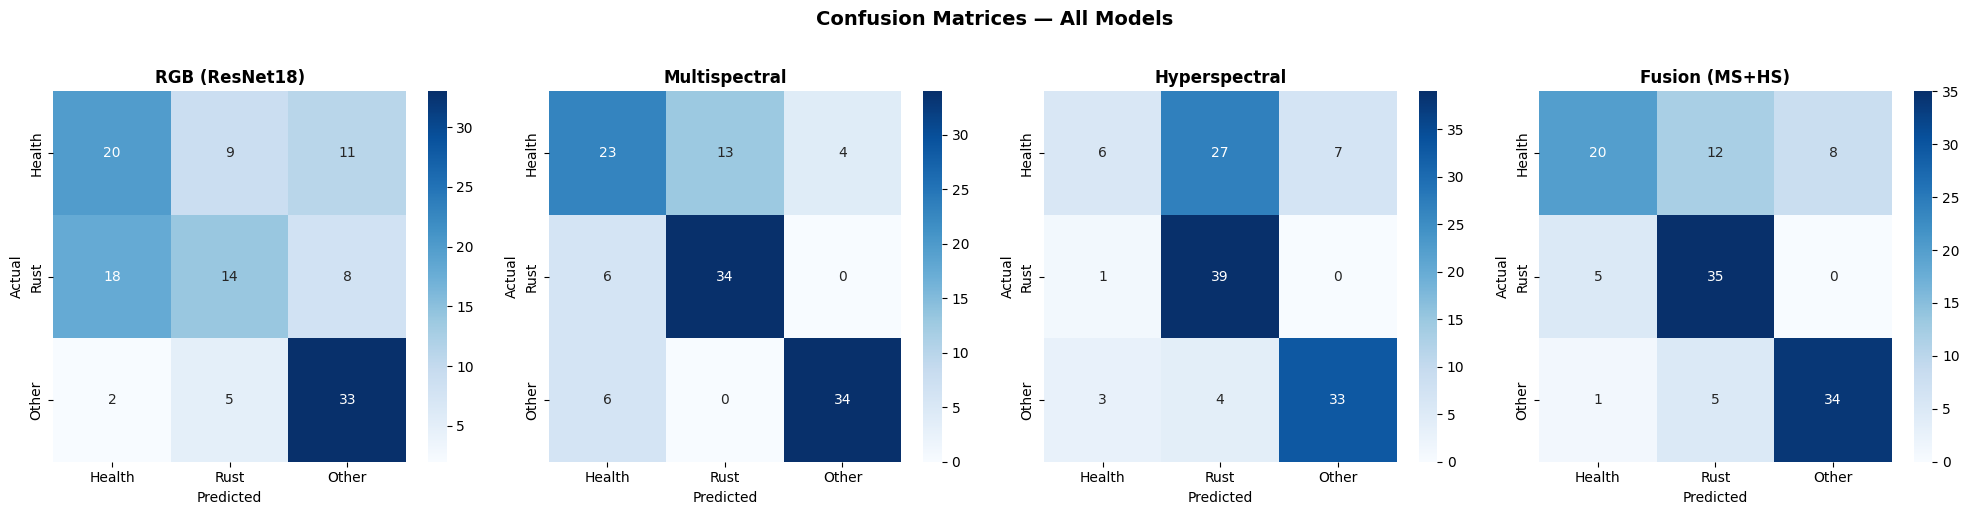

In [62]:
# Confusion Matrices for all models:


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Health", "Rust", "Other"],
                yticklabels=["Health", "Rust", "Other"],
                ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# ── Get predictions from each model ───────────────────────────
def get_preds(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def get_preds_fusion(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ms, hs, labels in dataloader:
            ms, hs = ms.to(device), hs.to(device)
            preds = torch.argmax(model(ms, hs), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_true_rgb,    y_pred_rgb    = get_preds(rgb_model, rgb_val_loader)
y_true_ms,     y_pred_ms     = get_preds(ms_model,  ms_val_loader)
y_true_hs,     y_pred_hs     = get_preds(hs_model,  hs_val_loader)
y_true_fusion, y_pred_fusion = get_preds_fusion(model, val_loader)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_confusion_matrix(axes[0], y_true_rgb,    y_pred_rgb,    "RGB (ResNet18)")
plot_confusion_matrix(axes[1], y_true_ms,     y_pred_ms,     "Multispectral")
plot_confusion_matrix(axes[2], y_true_hs,     y_pred_hs,     "Hyperspectral")
plot_confusion_matrix(axes[3], y_true_fusion, y_pred_fusion, "Fusion (MS+HS)")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

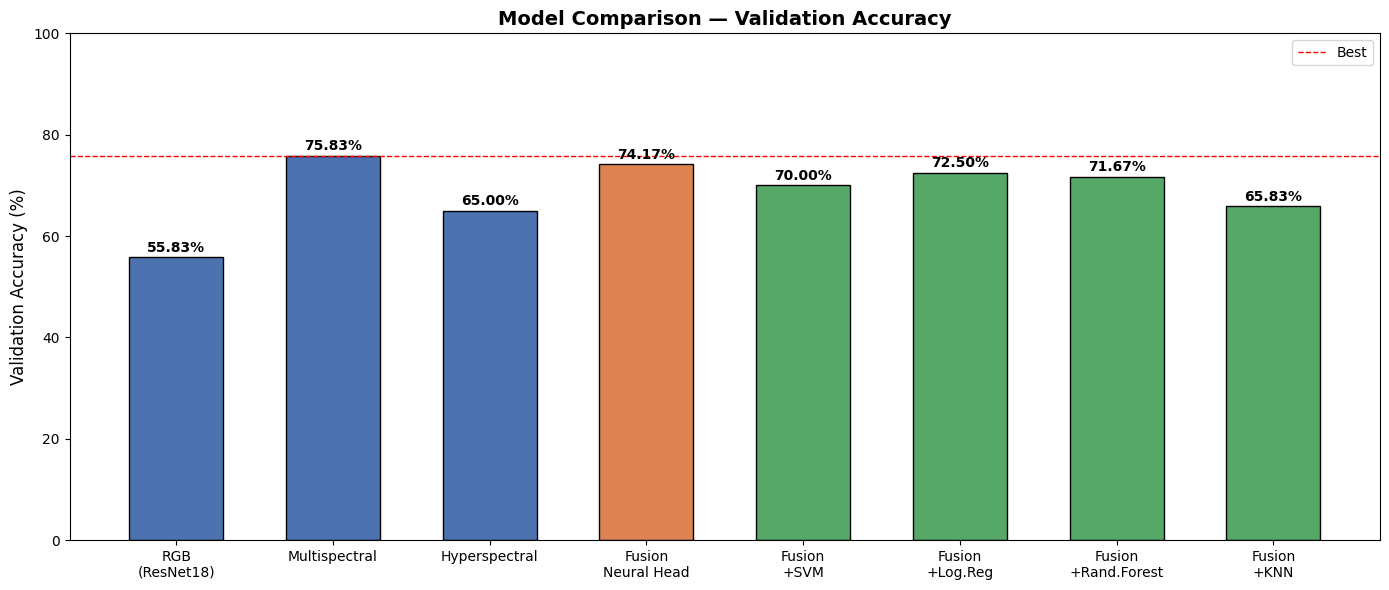

In [63]:
# Overall Accuracy Bar Chart:


model_names = [
    "RGB\n(ResNet18)",
    "Multispectral",
    "Hyperspectral",
    "Fusion\nNeural Head",
    "Fusion\n+SVM",
    "Fusion\n+Log.Reg",
    "Fusion\n+Rand.Forest",
    "Fusion\n+KNN"
]

accuracies = [
    rgb_acc,
    ms_acc,
    hs_acc,
    fusion_nn_acc,
    results["SVM (RBF)"],
    results["Logistic Regression"],
    results["Random Forest"],
    results["KNN (k=5)"],
]

colors = ["#4C72B0"] * 3 + ["#DD8452"] + ["#55A868"] * 4

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(model_names, [a * 100 for a in accuracies], color=colors, edgecolor="black", width=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{acc:.2%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 100)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison — Validation Accuracy", fontsize=14, fontweight="bold")
ax.axhline(y=max(a * 100 for a in accuracies), color="red", linestyle="--", linewidth=1, label="Best")
ax.legend()
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

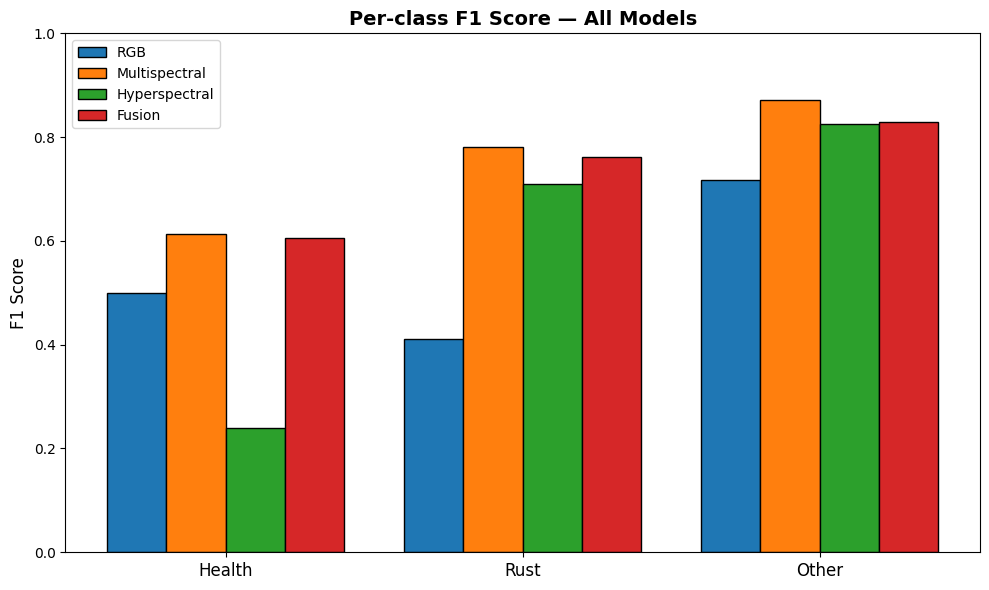

In [64]:
# Per-class F1 Score Comparison:


from sklearn.metrics import f1_score

classes    = ["Health", "Rust", "Other"]
all_y_true = [y_true_rgb, y_true_ms, y_true_hs, y_true_fusion]
all_y_pred = [y_pred_rgb, y_pred_ms, y_pred_hs, y_pred_fusion]
model_lbls = ["RGB", "Multispectral", "Hyperspectral", "Fusion"]

f1_scores = []
for y_true, y_pred in zip(all_y_true, all_y_pred):
    f1 = f1_score(y_true, y_pred, average=None)
    f1_scores.append(f1)

x     = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
for i, (lbl, f1) in enumerate(zip(model_lbls, f1_scores)):
    ax.bar(x + i * width, f1, width, label=lbl, edgecolor="black")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Per-class F1 Score — All Models", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

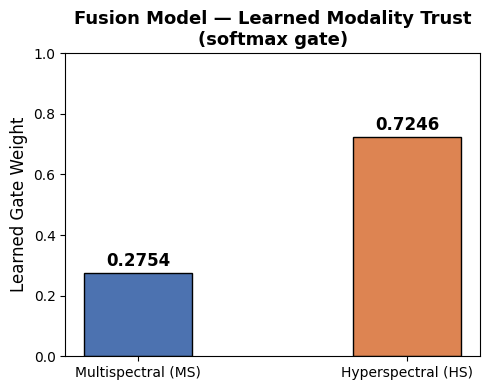


MS gate weight : 0.2754
HS gate weight : 0.7246
→ Model trusts HS more


In [66]:
# Gate Weight Visualization (unique to your Fusion model)

gates = torch.softmax(model.gate, dim=0).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Multispectral (MS)", "Hyperspectral (HS)"],
              gates, color=["#4C72B0", "#DD8452"], edgecolor="black", width=0.4)

for bar, g in zip(bars, gates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{g:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1)
ax.set_ylabel("Learned Gate Weight", fontsize=12)
ax.set_title("Fusion Model — Learned Modality Trust\n(softmax gate)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gate_weights.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMS gate weight : {gates[0]:.4f}")
print(f"HS gate weight : {gates[1]:.4f}")
print(f"→ Model trusts {'HS' if gates[1] > gates[0] else 'MS'} more")

In [68]:
from google.colab import files
import rasterio
import torch
import numpy as np
import torchvision.transforms as transforms

CLASS_NAMES = {0: "🌿 Healthy", 1: "🦠 Rust", 2: "⚠️  Other"}

def predict_crop():

    # ── Upload MS file ────────────────────────────────────────
    print("Step 1: Upload your MS file (5-band .tif):")
    ms_up   = files.upload()
    ms_path = list(ms_up.keys())[0]

    # ── Upload HS file ────────────────────────────────────────
    print("\nStep 2: Upload your HS file (125-band .tif):")
    hs_up   = files.upload()
    hs_path = list(hs_up.keys())[0]

    # ── Preprocess MS ─────────────────────────────────────────
    with rasterio.open(ms_path) as src:
        ms_arr = src.read().astype(np.float32) / 65535.0   # (5, H, W)

    ms_t = torch.from_numpy(ms_arr[:MS_BANDS]).float()
    ms_t = transforms.Resize(
        (112, 112),
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    )(ms_t)
    ms_mean_t = torch.tensor(MS_MEAN, dtype=torch.float32).view(MS_BANDS, 1, 1)
    ms_std_t  = torch.tensor(MS_STD,  dtype=torch.float32).view(MS_BANDS, 1, 1)
    ms_t = (ms_t - ms_mean_t) / (ms_std_t + 1e-6)
    ms_t = ms_t.unsqueeze(0).to(device)                    # (1, 5, 112, 112)

    # ── Preprocess HS ─────────────────────────────────────────
    with rasterio.open(hs_path) as src:
        hs_arr = src.read().astype(np.float32) / 65535.0   # (125, H, W)

    hs_arr  = hs_arr[HS_BAND_START:HS_BAND_END]            # (101, H, W)
    hs_t    = torch.from_numpy(hs_arr).float()
    hs_mean_t = torch.tensor(HS_MEAN, dtype=torch.float32).view(HS_BANDS, 1, 1)
    hs_std_t  = torch.tensor(HS_STD,  dtype=torch.float32).view(HS_BANDS, 1, 1)
    hs_t = (hs_t - hs_mean_t) / (hs_std_t + 1e-6)
    hs_t = hs_t.unsqueeze(0).to(device)                    # (1, 101, 32, 32)

    # ── Predict ───────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(ms_t, hs_t)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(np.argmax(probs))

    # ── Show result ───────────────────────────────────────────
    print("\n" + "="*40)
    print(f"  Prediction : {CLASS_NAMES[pred]}")
    print("="*40)
    print(f"  Healthy    : {probs[0]:.1%}")
    print(f"  Rust       : {probs[1]:.1%}")
    print(f"  Other      : {probs[2]:.1%}")
    print("="*40)

predict_crop()

Step 1: Upload your MS file (5-band .tif):


Saving val_000a83c1.tif to val_000a83c1.tif

Step 2: Upload your HS file (125-band .tif):


Saving val_000a83c1.tif to val_000a83c1 (1).tif

  Prediction : 🌿 Healthy
  Healthy    : 48.1%
  Rust       : 19.1%
  Other      : 32.8%
